In [10]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import argparse
import os

In [11]:
input_folder = r"C:/Users/ranor/Desktop/code/Data_normalized"
output_folder = r"C:/Users/ranor/Desktop/code/tables"

In [12]:
def remove_printed_text_and_lines(img: np.ndarray) -> np.ndarray:
    # Preprocesses image to remove horizontal ruled lines and noise, isolating handwriting
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    # Create binary inverse (white text on black background)
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)
    height, width = img.shape[:2]

    # Detect and remove horizontal lines using Hough Transform
    lines_mask = np.zeros_like(binary)
    lines = cv2.HoughLinesP(binary, 1, np.pi/180, threshold=100, minLineLength=width*0.3, maxLineGap=10)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            # Draw thick lines over detected ruled lines to mask them
            cv2.line(lines_mask, (x1, y1), (x2, y2), 255, 8)

    # Subtract lines from the binary image
    binary_no_lines = cv2.bitwise_and(binary, cv2.bitwise_not(lines_mask))
    
    # Filter out noise and irrelevant regions using Connected Components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_no_lines, connectivity=8)
    handwriting_mask = np.zeros_like(binary_no_lines)

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]
        # Define regions to ignore (header, footer) and noise threshold
        is_bottom_region = (y + h) > height * 0.85
        is_top_region = y < height * 0.1
        is_too_small = area < 15

        # Keep only valid handwriting components
        if not (is_bottom_region or is_top_region or is_too_small):
            handwriting_mask[labels == i] = 255

    # Invert back to normal (black text on white background)
    result = cv2.bitwise_not(handwriting_mask)
    return result

In [13]:
def calculate_stroke_thickness_pure(img: np.ndarray) -> float:
    # Calculates average stroke thickness using Distance Transform
    handwriting_only = remove_printed_text_and_lines(img)

    if len(handwriting_only.shape) == 3:
        gray = cv2.cvtColor(handwriting_only, cv2.COLOR_BGR2GRAY)
    else:
        gray = handwriting_only

    # Binary thresholding
    _, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    inverted = cv2.bitwise_not(binary)

    # Distance Transform: calculates distance of each pixel to the nearest zero pixel (background)
    # This effectively measures the "skeleton" width at every point
    dist_transform = cv2.distanceTransform(inverted, cv2.DIST_L2, 5)
    text_distances = dist_transform[dist_transform > 0]

    # Calculate ratio of handwriting pixels to total area
    total_pixels = inverted.shape[0] * inverted.shape[1]
    handwriting_ratio = len(text_distances) / total_pixels if total_pixels > 0 else 0

    # Safety check: If page is empty or has too little content, try raw image or return 0
    MINIMUM_CONTENT_THRESHOLD = 0.003 
    if len(text_distances) == 0 or handwriting_ratio < MINIMUM_CONTENT_THRESHOLD:
        if len(img.shape) == 3:
            gray_raw = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray_raw = img

        _, binary_raw = cv2.threshold(gray_raw, 127, 255, cv2.THRESH_BINARY)
        inverted_raw = cv2.bitwise_not(binary_raw)

        dist_transform_raw = cv2.distanceTransform(inverted_raw, cv2.DIST_L2, 5)
        text_distances = dist_transform_raw[dist_transform_raw > 0]

        if len(text_distances) == 0:
            return 0.0
    
    # Mean distance is the radius, so multiply by 2 for diameter (thickness)
    avg_thickness = np.mean(text_distances) * 2

    return avg_thickness


In [14]:
def process_images_for_stroke_thickness(
    input_dir: str,
    output_excel: str,
    extensions: tuple = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
) -> pd.DataFrame:
    # Main processing loop: iterates images, calculates raw thickness, and normalizes results

    image_files = set()
    for ext in extensions:
        image_files.update(Path(input_dir).glob(f'*{ext}'))
        image_files.update(Path(input_dir).glob(f'*{ext.upper()}'))

    image_files = sorted(list(image_files))
    total = len(image_files)

    print(f"Found {total} images to analyze")
    print(f"Output Excel file: {output_excel}")
    
    raw_thickness_values = []
    temp_results = []

    # Step 1: Calculate raw thickness for all images
    for idx, img_path in enumerate(image_files, 1):
        try:
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

            if img is None:
                print(f"[WARNING] Could not read: {img_path.name}")
                temp_results.append({
                    'Image_Number': idx,
                    'Filename': img_path.name,
                    'Raw_Thickness': None
                })
                continue

            stroke_thickness = calculate_stroke_thickness_pure(img)
            raw_thickness_values.append(stroke_thickness)

            temp_results.append({
                'Image_Number': idx,
                'Filename': img_path.name,
                'Raw_Thickness': stroke_thickness
            })

            if idx % 500 == 0:
                print(f"Processed {idx}/{total} images...")

        except Exception as e:
            print(f"[ERROR] Failed to process {img_path.name}: {str(e)}")
            temp_results.append({
                'Image_Number': idx,
                'Filename': img_path.name,
                'Raw_Thickness': None
            })

    print(f"Analysis complete!")

    # Step 2: Normalize values to 0-1 range based on dataset min/max
    valid_values = [r for r in raw_thickness_values if r is not None and r > 0]
    min_thickness = min(valid_values) if valid_values else 0.0
    max_thickness = max(valid_values) if valid_values else 1.0
    thickness_range = max_thickness - min_thickness

    print(f"\nNormalizing to [0, 1] range:")
    print(f"Raw min: {min_thickness:.3f} pixels")
    print(f"Raw max: {max_thickness:.3f} pixels")

    results = []
    for item in temp_results:
        if item['Raw_Thickness'] is None:
            normalized_value = None
        elif item['Raw_Thickness'] == 0:
            normalized_value = 0.0
        elif thickness_range == 0:
            normalized_value = 0.5
        else:
            # Min-Max Normalization formula
            normalized_value = (item['Raw_Thickness'] - min_thickness) / thickness_range

        results.append({
            'Image_Number': item['Image_Number'],
            'Filename': item['Filename'],
            'Stroke_Thickness': round(normalized_value, 3) if normalized_value is not None else None
        })

    # Save to Excel
    df = pd.DataFrame(results)
    df.to_excel(output_excel, index=False, sheet_name='Stroke Thickness')

    print(f"\nExcel file saved: {output_excel}")
    print("\nNormalized Stroke Thickness Statistics (0-1 range):")
    print(f"Min: {df['Stroke_Thickness'].min():.3f}")
    print(f"Max: {df['Stroke_Thickness'].max():.3f}")
    print(f"Mean: {df['Stroke_Thickness'].mean():.3f}")
    print(f"Median: {df['Stroke_Thickness'].median():.3f}")
    print(f"Std Dev: {df['Stroke_Thickness'].std():.3f}")

    return df

In [15]:
process_images_for_stroke_thickness(input_dir=input_folder, output_excel=os.path.join(output_folder, 'stroke_thickness.xlsx'))

Found 2512 images to analyze
Output Excel file: C:/Users/ranor/Desktop/code/tables\stroke_thickness.xlsx
Processed 500/2512 images...
Processed 1000/2512 images...
Processed 1500/2512 images...
Processed 2000/2512 images...
Processed 2500/2512 images...
Analysis complete!

Normalizing to [0, 1] range:
Raw min: 2.031 pixels
Raw max: 3.068 pixels

Excel file saved: C:/Users/ranor/Desktop/code/tables\stroke_thickness.xlsx

Normalized Stroke Thickness Statistics (0-1 range):
Min: 0.000
Max: 1.000
Mean: 0.294
Median: 0.290
Std Dev: 0.109


,Image_Number,Filename,Stroke_Thickness
0,1,txt (1).png,0.368
1,2,txt (10).png,0.065
2,3,txt (100).png,0.348
3,4,txt (1000).png,0.487
4,5,txt (1001).png,0.301
...,...,...,...
2507,2508,txt (995).png,0.394
2508,2509,txt (996).png,0.339
2509,2510,txt (997).png,0.191
2510,2511,txt (998).png,0.233


Found 2512 images to analyze
Output Excel file: C:/Users/ranor/Desktop/code/tables\stroke_thickness.xlsx
Processed 500/2512 images...
Processed 1000/2512 images...
Processed 1500/2512 images...
Processed 2000/2512 images...
Processed 2500/2512 images...
Analysis complete!

Normalizing to [0, 1] range:
Raw min: 2.031 pixels
Raw max: 3.068 pixels

Excel file saved: C:/Users/ranor/Desktop/code/tables\stroke_thickness.xlsx

Normalized Stroke Thickness Statistics (0-1 range):
Min: 0.000
Max: 1.000
Mean: 0.294
Median: 0.290
Std Dev: 0.109


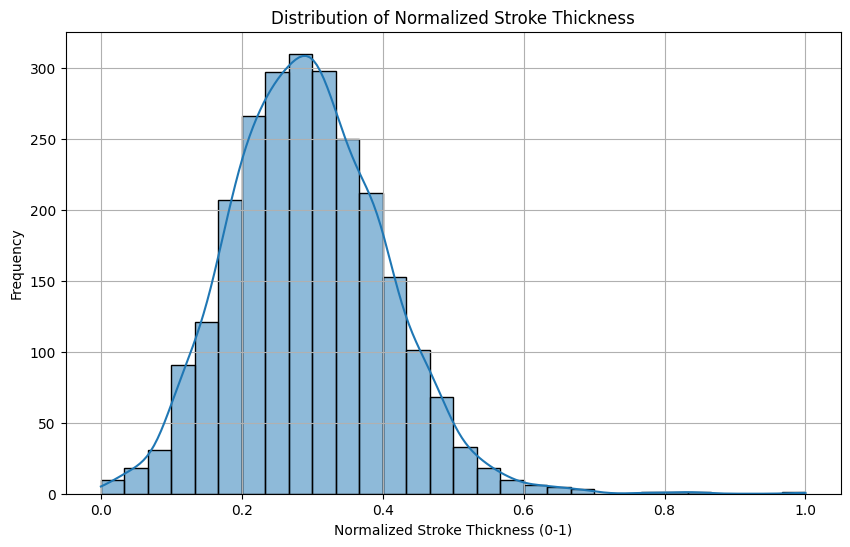

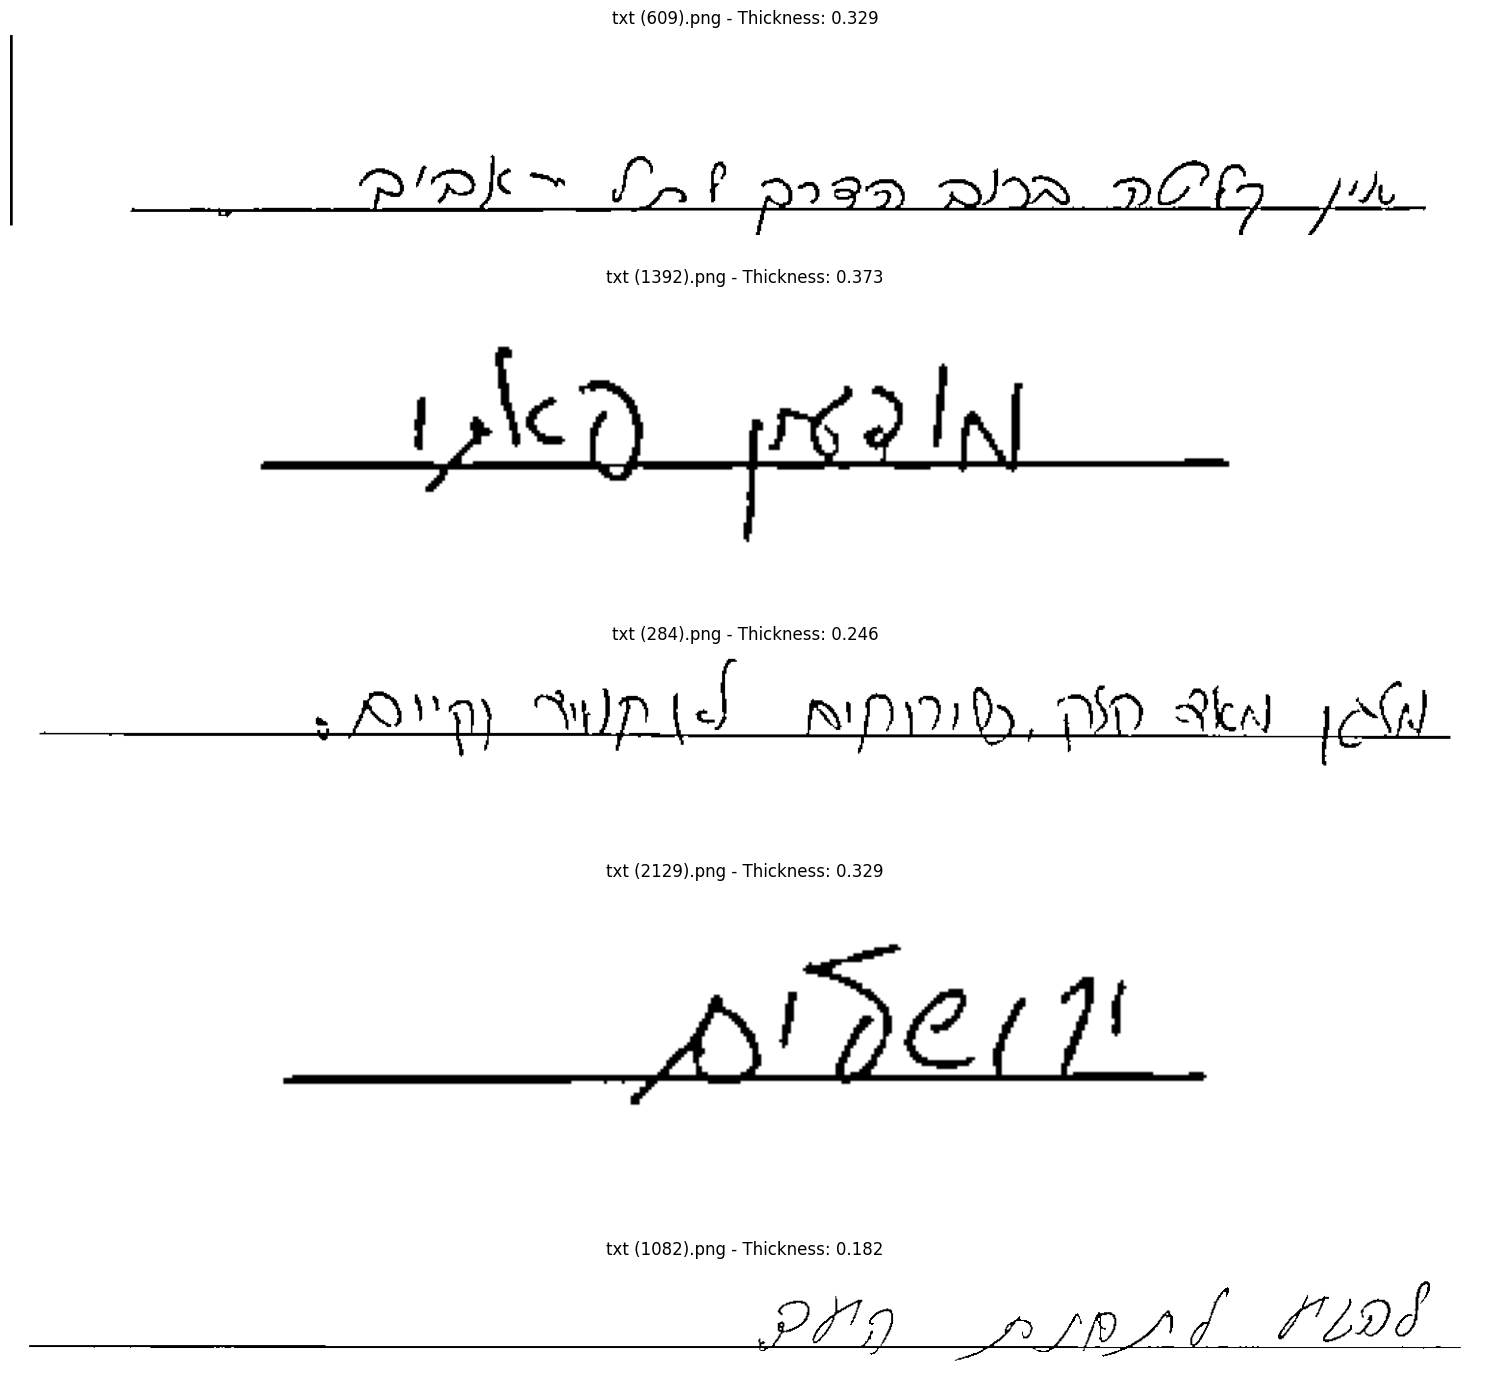

In [ ]:
def images_with_thickness(df: pd.DataFrame, input_dir: str, num_images: int = 5):
    import matplotlib.pyplot as plt

    sample_df = df.dropna(subset=['Stroke_Thickness']).sample(n=num_images, random_state=42)
    
    plt.figure(figsize=(15, 3 * num_images))
    for idx, row in enumerate(sample_df.itertuples(), 1):
        img_path = os.path.join(input_dir, row.Filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            plt.subplot(num_images, 1, idx)
            plt.imshow(img, cmap='gray')
            plt.title(f"{row.Filename} - Thickness: {row.Stroke_Thickness:.3f}")
            plt.axis('off')
        else:
            print(f"[WARNING] Could not read image for visualization: {row.Filename}")

    plt.tight_layout()
    plt.show()

df_stroke_thickness = process_images_for_stroke_thickness(input_dir=input_folder, output_excel=os.path.join(output_folder, 'stroke_thickness.xlsx'))
images_with_thickness(df_stroke_thickness, input_dir=input_folder)